### EX: Evaluating Performance

In this exercise, we will simulate a highly imbalanced SAM detection scenario to prove why flat accuracy is deceptive. We will train a Logistic Regression model and evaluate its performance using advanced tactical visualizations.

* **Generate Imbalanced Data:** Create a dataset where 95% of the sectors are "Clear" and 5% contain "Threats".

* **Train Model:** Train a Logistic Regression model to identify the hidden SAM sites based on simulated sensor features.

* **Calculate Metrics:** Output the Flat Accuracy, Precision, Recall, and F1-Score.

* **Visualize the Trade-offs:** Plot the Confusion Matrix, the ROC Curve, and the Precision-Recall Curve to visually determine the model's true operational effectiveness.

In [ ]:
# Run this code if your virtual environment does not have the required libraries installed. 
# You only need to run this once per environment.
!pip install keras tensorflow matplotlib numpy pydot graphviz

Flat Accuracy: 96.3%
Precision:   50.0%
Recall:      27.3%
F1-Score:    35.3%



c:\Users\codeh\471Book\jnb_env\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


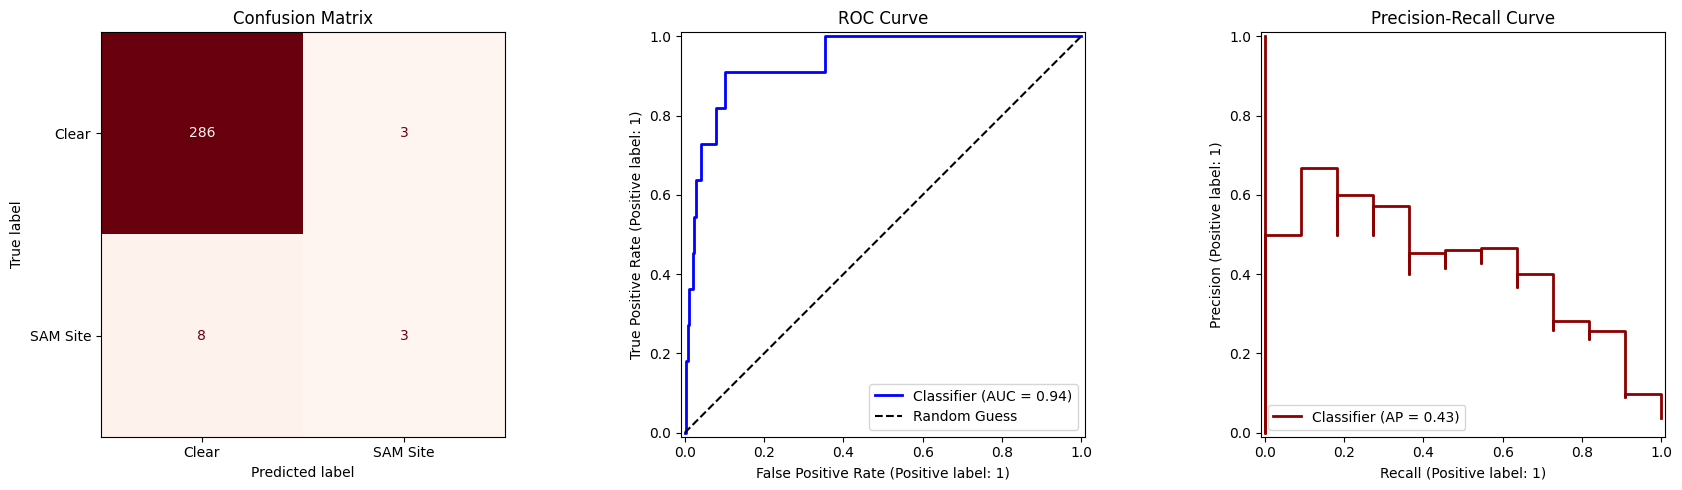

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

# 1. Generate Imbalanced Battlespace Data (1000 map sectors)
# 0 = Clear Sand (95%), 1 = Hidden SAM Site (5%)
X, y = make_classification(n_samples=1000, n_features=4, n_informative=2, 
                           n_redundant=0, weights=[0.95, 0.05], random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train a Threat Detection Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict hard classes (0 or 1) and raw probabilities (0.0 to 1.0)
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1] # Get probabilities for the "SAM Site" class

# 3. Calculate Operational Metrics
flat_accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0) 
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Flat Accuracy: {flat_accuracy * 100:.1f}%")
print(f"Precision:   {precision * 100:.1f}%")
print(f"Recall:      {recall * 100:.1f}%")
print(f"F1-Score:    {f1 * 100:.1f}%\n")

# 4. Plot Confusion Matrix, ROC Curve, and PR Curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clear', 'SAM Site'])
disp_cm.plot(cmap='Reds', ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# Plot B: ROC Curve
RocCurveDisplay.from_predictions(y_test, y_probs, ax=axes[1], color='blue', linewidth=2)
axes[1].set_title("ROC Curve")
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess') # Baseline
axes[1].legend()

# Plot C: Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_probs, ax=axes[2], color='darkred', linewidth=2)
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

### Interpreting the Results

This lab proves that evaluating model performance requires deep contextual awareness.

Look at the {term}`Confusion Matrix`. Despite having a high flat accuracy (because the model correctly identifies the massive amount of empty sand), the model missed several SAM sites (False Negatives). In warfare, evaluating the balance between False Positives (wasting resources) and False Negatives (missing threats) is often more important than the underlying algorithm itself.

To adjust this balance, commanders rely on the two curves on the right:

* {term}`ROC Curve (Receiver Operating Characteristic)`: This plots the True Positive Rate against the False Positive Rate across every possible probability threshold. The dotted black line represents a completely random guess. The closer the blue line pulls to the top-left corner (An Area Under the Curve / AUC of 1.0), the better the model is at distinguishing between sand and SAMs.

* {term}`Precision-Recall (PR) Curve`: When dealing with highly imbalanced data (like a 95% / 5% split), the ROC curve can sometimes look overly optimistic. The PR curve focuses *only* on the minority threat class. It visualizes the brutal tactical tradeoff: if you want to increase your {term}`Recall (Sensitivity)` (finding every single SAM site), you must lower your threshold, which inevitably drops your {term}`Precision` (you will accidentally bomb a lot of empty sand).

By analyzing these curves, an operational commander can manually set the model's trigger threshold to favor the exact risk profile required for the mission.